# Entson Company — Minimal Cash Balance Simulation
### Monte Carlo simulation of monthly cash flows, loans, and interest

**Problem summary:**
- Monthly sales are **normally distributed** (Nov–Jul, means and SDs given)
- Receipts lag sales: `R_t = 0.2·S_{t-2} + 0.6·S_{t-1} + 0.2·S_t`
- Material/labour costs = **80%** of next month's expected sales, paid 1 month early
- Fixed costs **$250K/month**, extra taxes in March ($150K) and June ($50K + $50K dividends)
- Starting cash: **$250K** · Minimum cash balance: **$250K**
- Short-term loans taken if balance falls below minimum (1% monthly interest)
- Cash earns **0.5%/month** interest

**Key outputs:** maximum loan required, total interest paid, loan path over time


In [1]:
import warnings; warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot  as plt
import matplotlib.ticker  as mticker
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi"       : 130,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "figure.facecolor" : "#FAFAFA",
    "axes.facecolor"   : "#FAFAFA",
})

RNG    = np.random.default_rng(seed=42)
N_SIMS = 10_000
print(f"Libraries loaded ✓   |   N_SIMS = {N_SIMS:,}")


Libraries loaded ✓   |   N_SIMS = 10,000


In [2]:
# ── Model parameters (all monetary values in $000s) ──────────────────────────
MONTHS = ["Nov", "Dec", "Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul"]

MEAN_SALES = np.array([1500, 1600, 1800, 1500, 1900, 2600, 2400, 1900, 1300])
STD_SALES  = np.array([  70,   75,   80,   80,  100,  125,  120,   90,   70])

# Receipt weights: R_t = 0.2*S_{t-2} + 0.6*S_{t-1} + 0.2*S_t
W_2, W_1, W_0 = 0.2, 0.6, 0.2

# Costs
FIXED_COST        = 250          # every month ($000s)
EXTRA_COSTS       = {            # month_index (0=Nov) → extra one-off costs
    4: 150,                      # March: taxes
    7:  50 + 50,                 # June:  taxes + dividends
}
MAT_LABOR_PCT     = 0.80         # % of NEXT month's sales
INITIAL_CASH      = 250
MIN_CASH_BALANCE  = 250
LOAN_RATE         = 0.01         # 1% per month
CASH_RATE         = 0.005        # 0.5% per month on cash balance

# Simulation window: Jan(idx=2) through Jun(idx=7)  → 6 months
SIM_START = 2   # Jan index in MONTHS array
SIM_END   = 7   # Jun index (inclusive)
SIM_MONTHS = MONTHS[SIM_START:SIM_END+1]   # ['Jan','Feb','Mar','Apr','May','Jun']
print("Parameters set ✓")
print(f"Simulation window: {SIM_MONTHS[0]} → {SIM_MONTHS[-1]}  ({len(SIM_MONTHS)} months)")


Parameters set ✓
Simulation window: Jan → Jun  (6 months)


In [3]:
# ── Draw all sales scenarios at once ─────────────────────────────────────────
# Shape: (9 months, N_SIMS)  — all months Nov–Jul needed for receipt lag calc
sales = (
    RNG.standard_normal(size=(len(MONTHS), N_SIMS))   # standard normals
    * MEAN_SALES[:, None]  * 0                        # placeholder — override below
)

# Proper broadcast: mean + std * z
sales = MEAN_SALES[:, None] + STD_SALES[:, None] * RNG.standard_normal(
            size=(len(MONTHS), N_SIMS))
sales = np.maximum(sales, 0)   # sales can't be negative

print(f"Sales array shape: {sales.shape}  (months × simulations)")
print()
pd.DataFrame(
    {"Month": MONTHS,
     "Mean drawn": sales.mean(axis=1).round(1),
     "Std drawn" : sales.std(axis=1).round(1),
     "Mean param": MEAN_SALES,
     "Std param" : STD_SALES}
).set_index("Month")


Sales array shape: (9, 10000)  (months × simulations)



,Mean drawn,Std drawn,Mean param,Std param
Month,,,,
Nov,1498.3,70.3,1500,70
Dec,1599.6,75.2,1600,75
Jan,1800.2,80.4,1800,80
Feb,1499.9,79.8,1500,80
Mar,1900.7,101.5,1900,100
Apr,2598.7,125.4,2600,125
May,2400.6,119.4,2400,120
Jun,1901.0,89.5,1900,90
Jul,1301.8,70.0,1300,70


In [4]:
# ── Month-by-month cash flow simulation ──────────────────────────────────────
# Outputs per simulation path, for Jan–Jun (6 months):
#   beginning_cash, interest_on_cash, receipts, fixed_cost, extra_cost,
#   mat_labor_cost, loan_payback_principal, loan_payback_interest,
#   cash_before_loan, loan_amount, final_cash

n_sim_months = len(SIM_MONTHS)   # 6

# Storage arrays: shape (6, N_SIMS)
beg_cash      = np.zeros((n_sim_months, N_SIMS))
int_on_cash   = np.zeros((n_sim_months, N_SIMS))
receipts      = np.zeros((n_sim_months, N_SIMS))
fixed_costs   = np.zeros((n_sim_months, N_SIMS))
extra_costs   = np.zeros((n_sim_months, N_SIMS))
mat_labor     = np.zeros((n_sim_months, N_SIMS))
loan_pb_prin  = np.zeros((n_sim_months, N_SIMS))
loan_pb_int   = np.zeros((n_sim_months, N_SIMS))
cash_b4_loan  = np.zeros((n_sim_months, N_SIMS))
loan_amount   = np.zeros((n_sim_months, N_SIMS))
final_cash    = np.zeros((n_sim_months, N_SIMS))

prev_loan     = np.zeros(N_SIMS)   # loan carried from previous month

for t, (m_name, m_idx) in enumerate(
        zip(SIM_MONTHS, range(SIM_START, SIM_END + 1))):

    # ── Beginning cash
    if t == 0:
        beg_cash[t] = INITIAL_CASH
    else:
        beg_cash[t] = final_cash[t - 1]

    # ── Interest earned on beginning cash balance
    int_on_cash[t] = beg_cash[t] * CASH_RATE

    # ── Receipts: R_t = 0.2*S_{t-2} + 0.6*S_{t-1} + 0.2*S_t
    receipts[t] = (W_2 * sales[m_idx - 2]
                 + W_1 * sales[m_idx - 1]
                 + W_0 * sales[m_idx])

    # ── Fixed costs
    fixed_costs[t] = FIXED_COST

    # ── Extra one-off costs (taxes / dividends)
    extra_costs[t] = EXTRA_COSTS.get(m_idx, 0)

    # ── Material & labour: 80% of NEXT month's sales (paid this month)
    if m_idx + 1 < len(MONTHS):
        mat_labor[t] = MAT_LABOR_PCT * sales[m_idx + 1]
    else:
        mat_labor[t] = 0   # no next month data for July

    # ── Repay previous month's loan + interest
    loan_pb_prin[t] = prev_loan
    loan_pb_int[t]  = prev_loan * LOAN_RATE

    # ── Cash balance before new loan
    cash_b4_loan[t] = (beg_cash[t]
                     + int_on_cash[t]
                     + receipts[t]
                     - fixed_costs[t]
                     - extra_costs[t]
                     - mat_labor[t]
                     - loan_pb_prin[t]
                     - loan_pb_int[t])

    # ── Loan taken out if below minimum
    loan_amount[t] = np.maximum(MIN_CASH_BALANCE - cash_b4_loan[t], 0)

    # ── Final cash balance
    final_cash[t]  = cash_b4_loan[t] + loan_amount[t]

    # ── Carry loan forward
    prev_loan = loan_amount[t]

print("Simulation complete ✓")
print(f"Shape of each output array: {loan_amount.shape}  (sim_months × N_SIMS)")


Simulation complete ✓
Shape of each output array: (6, 10000)  (sim_months × N_SIMS)


In [5]:
# ── Summary statistics via pandas method chaining ────────────────────────────
def month_stats(arr, name):
    """Long-form stats DataFrame for one output variable."""
    return (
        pd.DataFrame(arr.T, columns=SIM_MONTHS)   # (N_SIMS, 6)
        .melt(var_name="month", value_name=name)
        .assign(month=lambda df: pd.Categorical(
                    df["month"], categories=SIM_MONTHS, ordered=True))
    )

df_loans     = month_stats(loan_amount,  "loan")
df_cash      = month_stats(final_cash,   "final_cash")
df_cb4       = month_stats(cash_b4_loan, "cash_before_loan")

# Key scalar outputs
max_loan_per_sim   = loan_amount.max(axis=0)          # max loan across months, per sim
total_interest_sim = (loan_amount * LOAN_RATE).sum(axis=0)   # total interest paid

summary = (
    pd.DataFrame({
        "Metric": ["Max loan ($000s)", "Total interest ($000s)"],
        "Mean"  : [max_loan_per_sim.mean(),   total_interest_sim.mean()],
        "Median": [np.median(max_loan_per_sim), np.median(total_interest_sim)],
        "P5"    : [np.percentile(max_loan_per_sim, 5),  np.percentile(total_interest_sim, 5)],
        "P95"   : [np.percentile(max_loan_per_sim, 95), np.percentile(total_interest_sim, 95)],
        "P(>0)" : [(max_loan_per_sim > 0).mean(),        (total_interest_sim > 0).mean()],
    })
    .set_index("Metric")
    .round(2)
)
print(f"Total invested in simulation: {N_SIMS:,} paths\n")
summary


Total invested in simulation: 10,000 paths



,Mean,Median,P5,P95,P(>0)
Metric,,,,,
Max loan ($000s),952.74,954.09,688.43,1213.05,1.0
Total interest ($000s),20.14,20.11,13.34,27.01,1.0


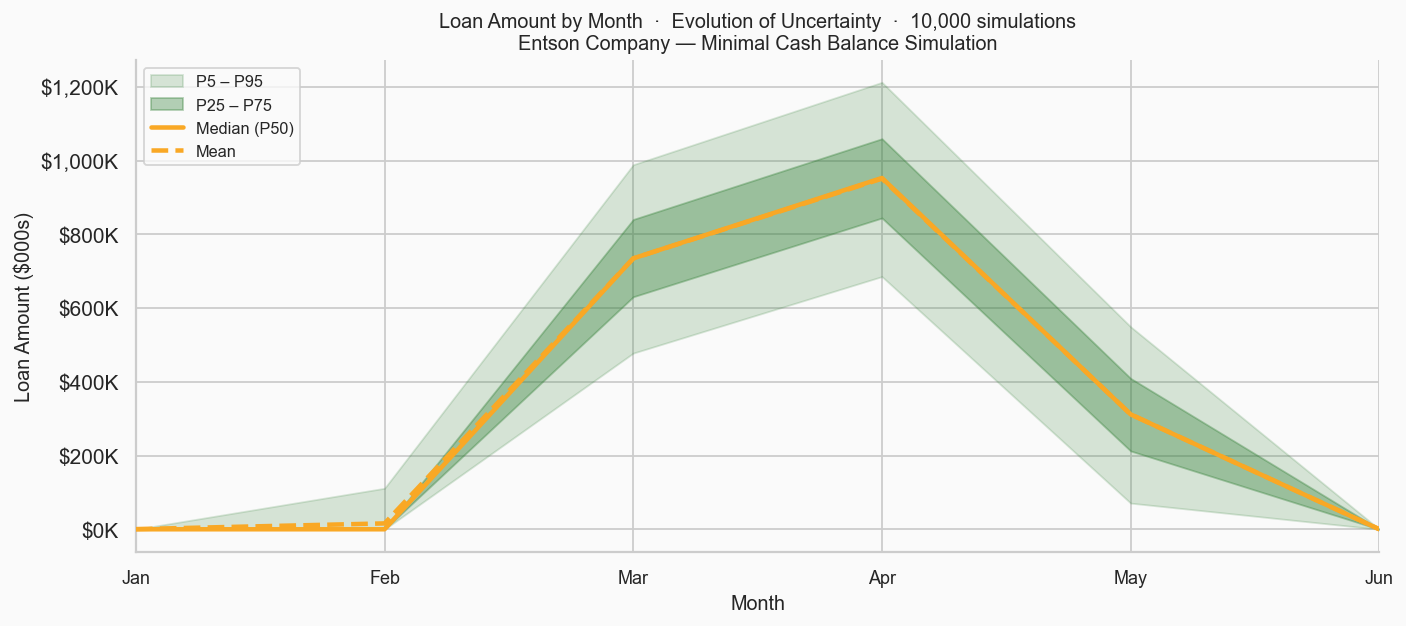

In [7]:
# ── Figure 1 · Loan Amount Fan Chart — Evolution of Uncertainty ──────────────
PERCS = [5, 25, 50, 75, 95]
month_idx = np.arange(len(SIM_MONTHS))

pct_loans = np.percentile(loan_amount, PERCS, axis=1)  # (5, 6)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

# Shaded uncertainty bands
ax.fill_between(month_idx, pct_loans[0], pct_loans[4],
                alpha=0.18, color="#2E7D32", label="P5 – P95")
ax.fill_between(month_idx, pct_loans[1], pct_loans[3],
                alpha=0.35, color="#2E7D32", label="P25 – P75")

# Median line (mean shown in yellow like @RISK)
ax.plot(month_idx, pct_loans[2], color="#F9A825", lw=2.5,
        zorder=5, label="Median (P50)")
ax.plot(month_idx, pct_loans.mean(axis=0) if False else
        loan_amount.mean(axis=1),
        color="#F9A825", lw=2.5, linestyle="--", zorder=5, label="Mean")

ax.set_xticks(month_idx)
ax.set_xticklabels(SIM_MONTHS, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Loan Amount ($000s)", fontsize=11)
ax.set_title(
    f"Loan Amount by Month  ·  Evolution of Uncertainty  ·  {N_SIMS:,} simulations\n"
    "Entson Company — Minimal Cash Balance Simulation",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(0, len(SIM_MONTHS) - 1)

plt.tight_layout()
# plt.savefig("loan_fan_chart.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()



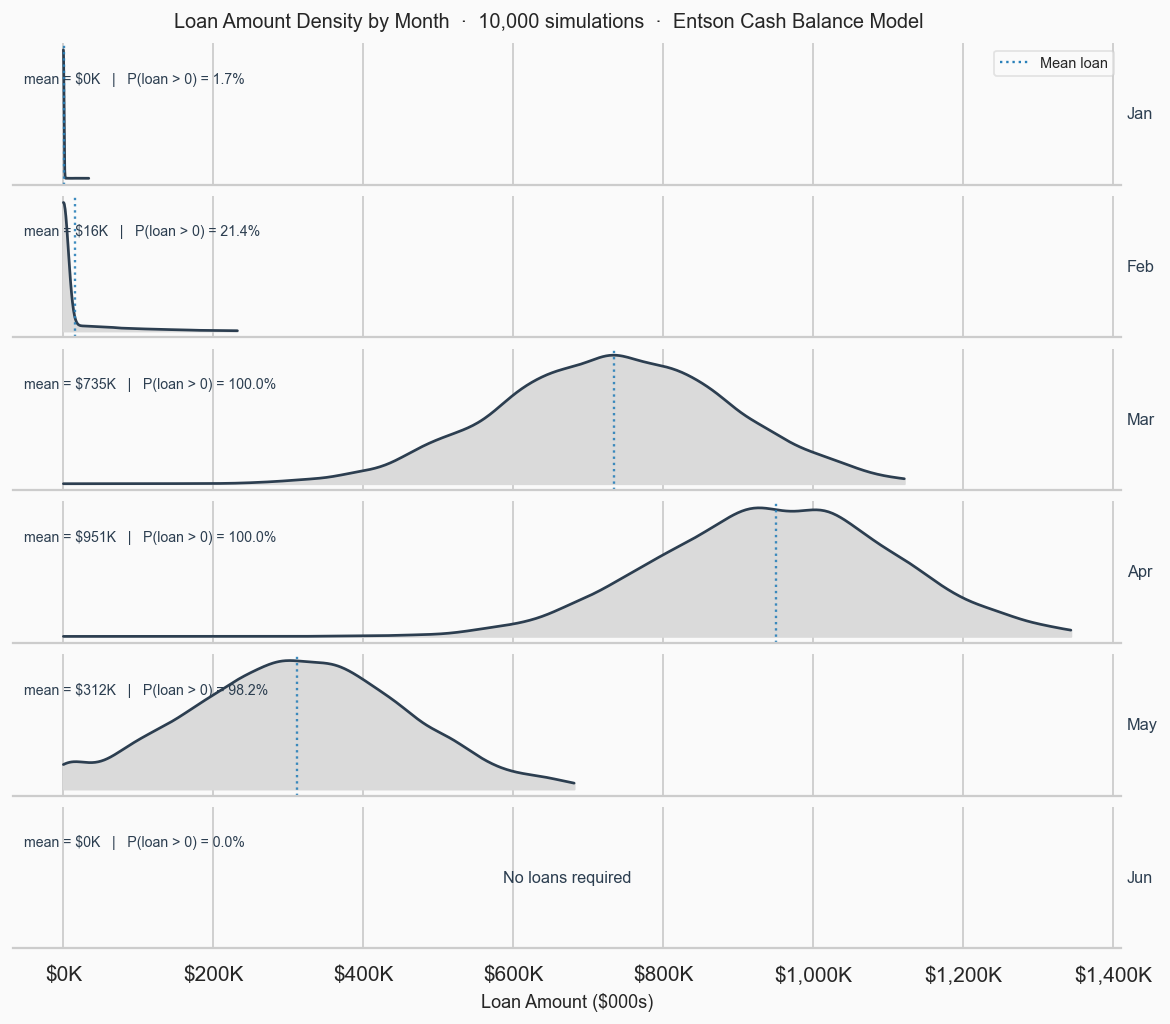

In [9]:
# ── Figure 3 · Faceted Density — Loan Amount per Month ───────────────────────
from scipy.stats import gaussian_kde

LINE_COLOR = "#2C3E50"
FILL_COLOR = "#DADADA"

fig, axes = plt.subplots(len(SIM_MONTHS), 1, figsize=(11, 8),
                         sharex=True,
                         gridspec_kw={"hspace": 0.08, "top": 0.94, "bottom": 0.07})
fig.patch.set_facecolor("#FAFAFA")

for ax, (t, m_name) in zip(axes, enumerate(SIM_MONTHS)):
    data = loan_amount[t]

    # Only plot KDE if there's variance (some months may be all zeros)
    nonzero = data[data > 0]
    if len(nonzero) > 100:
        kde = gaussian_kde(data)
        xs  = np.linspace(0, np.percentile(data, 99.5), 500)
        ys  = kde(xs)
        ax.fill_between(xs, ys, color=FILL_COLOR)
        ax.plot(xs, ys, color=LINE_COLOR, lw=1.5)
    else:
        ax.text(0.5, 0.5, "No loans required", transform=ax.transAxes,
                ha="center", va="center", fontsize=9, color=LINE_COLOR)

    mean_loan = data.mean()
    prob_loan = (data > 0).mean()

    if mean_loan > 0:
        ax.axvline(mean_loan, color="#2980B9", lw=1.3, linestyle=":", alpha=0.9)

    ax.set_ylabel(""); ax.set_yticks([])
    ax.set_xlabel("")
    ax.tick_params(left=False)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)
    ax.set_facecolor("#FAFAFA")

    ax.text(1.005, 0.5, m_name, transform=ax.transAxes,
            va="center", ha="left", fontsize=9, color=LINE_COLOR)
    ax.text(0.01, 0.72,
            f"mean = ${mean_loan:,.0f}K   |   P(loan > 0) = {prob_loan:.1%}",
            transform=ax.transAxes, fontsize=7.8, color=LINE_COLOR)

axes[-1].set_xlabel("Loan Amount ($000s)", fontsize=10)
axes[-1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

legend_elements = [
    Line2D([0],[0], color="#2980B9", lw=1.3, linestyle=":", label="Mean loan"),
]
axes[0].legend(handles=legend_elements, fontsize=8, loc="upper right", framealpha=0.5)

fig.suptitle(
    f"Loan Amount Density by Month  ·  {N_SIMS:,} simulations  ·  "
    "Entson Cash Balance Model",
    fontsize=11, y=0.97,
)
# plt.savefig("loan_density_facet.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


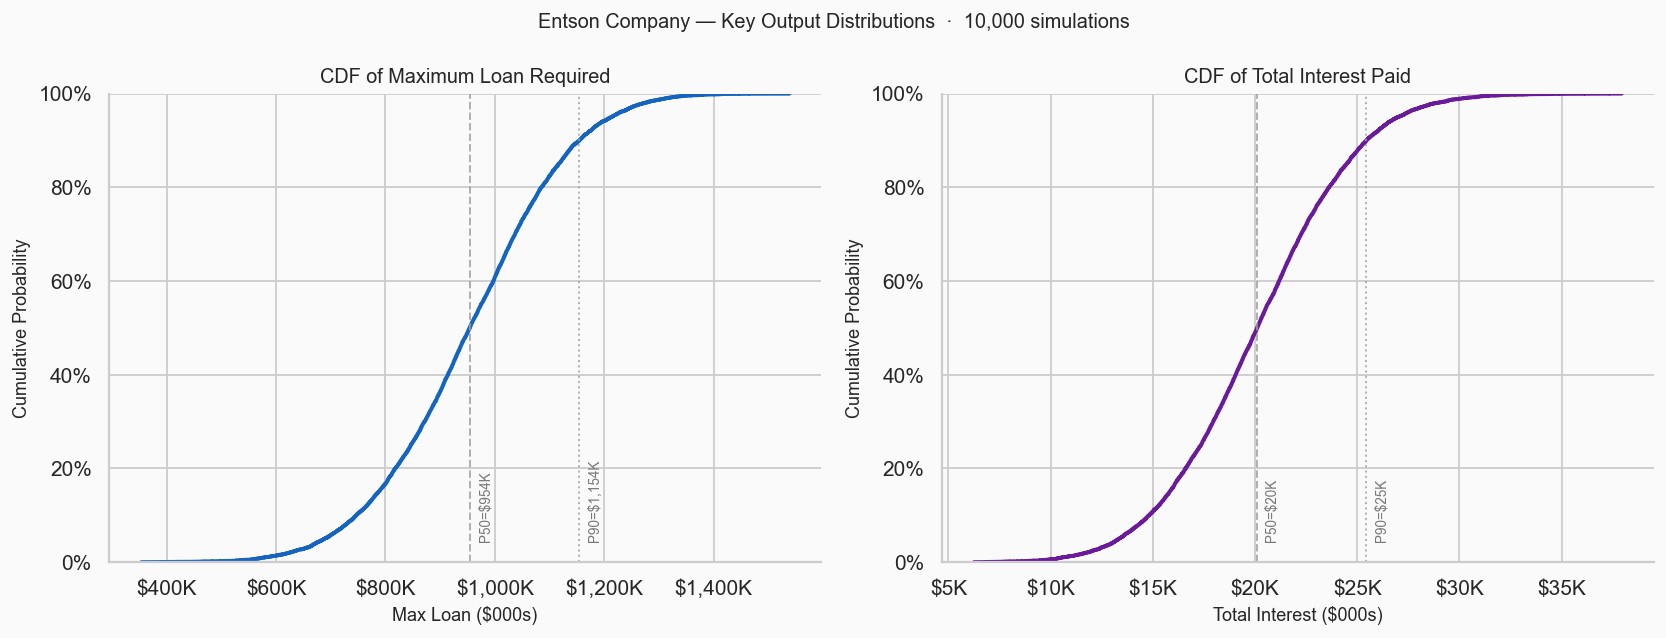

In [ ]:
# ── Figure 4 · CDF of Max Loan & Total Interest Paid ─────────────────────────
df_scalars = (
    pd.DataFrame({
        "max_loan"      : max_loan_per_sim,
        "total_interest": total_interest_sim,
    })
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#FAFAFA")

for ax, col, color, title, xlabel in [
    (axes[0], "max_loan",       "#1565C0",
     "CDF of Maximum Loan Required", "Max Loan ($000s)"),
    (axes[1], "total_interest", "#6A1B9A",
     "CDF of Total Interest Paid",   "Total Interest ($000s)"),
]:
    ax.set_facecolor("#FAFAFA")
    sns.ecdfplot(data=df_scalars, x=col, color=color, linewidth=2.2, ax=ax)

    # Percentile reference lines
    for p, ls in [(50, "--"), (90, ":")]:
        val = np.percentile(df_scalars[col], p)
        ax.axvline(val, color="#9E9E9E", lw=1.1, linestyle=ls, alpha=0.8)
        ax.text(val + df_scalars[col].max()*0.01, 0.05,
                f"P{p}=${val:,.0f}K", fontsize=7.5, color="#777", rotation=90)

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel("Cumulative Probability", fontsize=10)
    ax.set_title(title, fontsize=11)

fig.suptitle(
    f"Entson Company — Key Output Distributions  ·  {N_SIMS:,} simulations",
    fontsize=11,
)
plt.tight_layout()
# plt.savefig("cdf_outputs.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


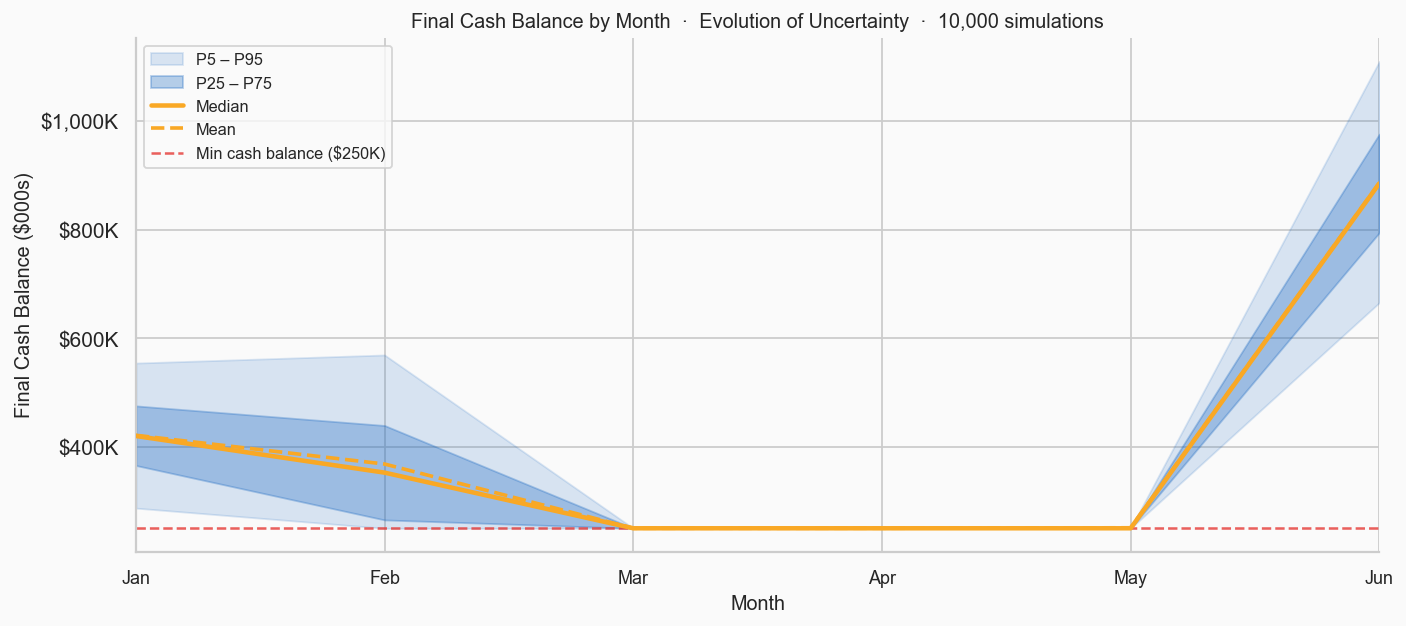

In [ ]:
# ── Figure 5 · Final Cash Balance Fan Chart ──────────────────────────────────
pct_cash = np.percentile(final_cash, [5, 25, 50, 75, 95], axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

ax.fill_between(month_idx, pct_cash[0], pct_cash[4],
                alpha=0.15, color="#1565C0", label="P5 – P95")
ax.fill_between(month_idx, pct_cash[1], pct_cash[3],
                alpha=0.30, color="#1565C0", label="P25 – P75")
ax.plot(month_idx, pct_cash[2], color="#F9A825", lw=2.5,
        zorder=5, label="Median")
ax.plot(month_idx, final_cash.mean(axis=1), color="#F9A825",
        lw=2, linestyle="--", zorder=5, label="Mean")

ax.axhline(MIN_CASH_BALANCE, color="#E53935", lw=1.4, linestyle="--",
           alpha=0.8, label=f"Min cash balance (${MIN_CASH_BALANCE:,}K)")

ax.set_xticks(month_idx)
ax.set_xticklabels(SIM_MONTHS, fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Final Cash Balance ($000s)", fontsize=11)
ax.set_title(
    f"Final Cash Balance by Month  ·  Evolution of Uncertainty  ·  {N_SIMS:,} simulations",
    fontsize=11,
)
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(0, len(SIM_MONTHS) - 1)

plt.tight_layout()
# plt.savefig("cash_fan_chart.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()


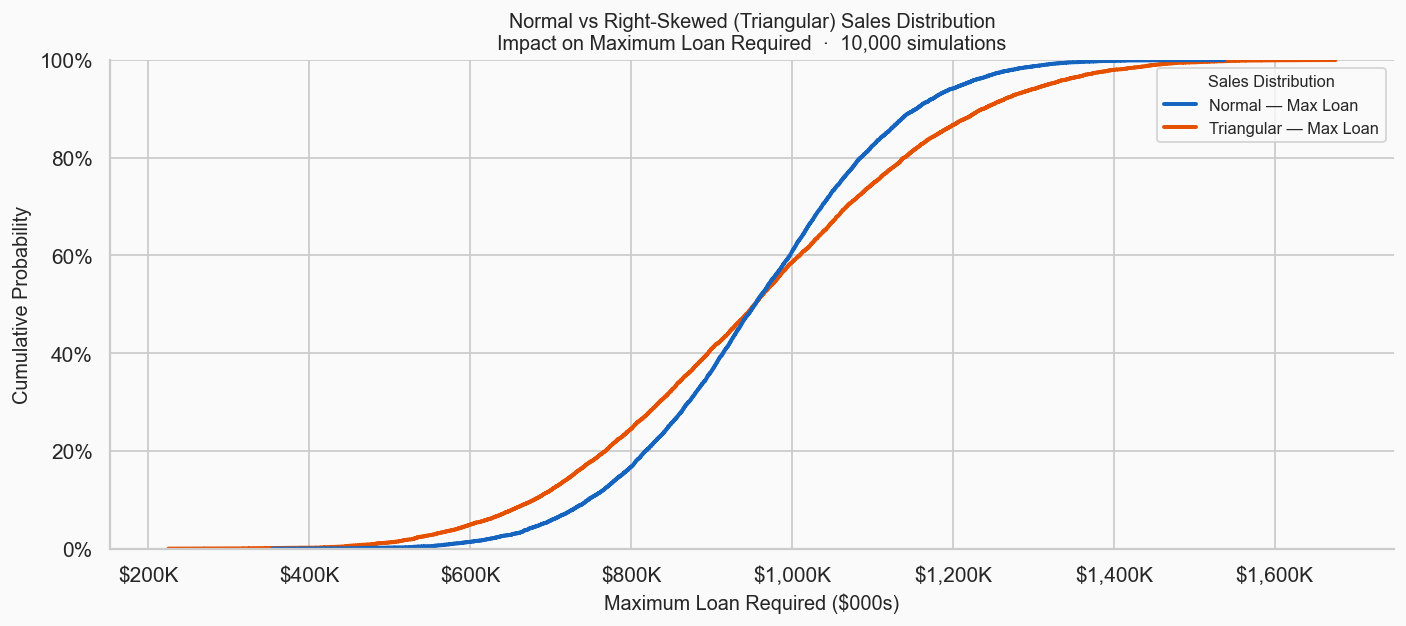

Normal    — Median max loan: $954.1K  |  Mean: $952.7K
Triangular — Median max loan: $953.4K  |  Mean: $954.9K


In [ ]:
# ── Extension: Skewed sales (RiskTriang equivalent) ──────────────────────────
# Triangular distribution approximates a right-skewed sales distribution.
# Parameters: min ≈ mean - 3*std, mode ≈ mean - 0.5*std, max ≈ mean + 3*std
# (skewed right: mode below mean)

def triangular_sales(rng, means, stds, n_sims):
    """Right-skewed triangular draws matching given means and stds approx."""
    sales_tri = np.zeros((len(means), n_sims))
    for i, (mu, sig) in enumerate(zip(means, stds)):
        lo   = mu - 2.5 * sig
        mode = mu - 0.3 * sig    # mode < mean → right skew
        hi   = mu + 4.0 * sig
        lo   = max(lo, 0)
        sales_tri[i] = rng.triangular(lo, mode, hi, size=n_sims)
    return sales_tri

sales_tri = triangular_sales(RNG, MEAN_SALES, STD_SALES, N_SIMS)

# Re-run simulation with triangular sales
prev_loan_tri = np.zeros(N_SIMS)
loan_amount_tri = np.zeros((len(SIM_MONTHS), N_SIMS))
final_cash_tri  = np.zeros((len(SIM_MONTHS), N_SIMS))
beg_cash_tri    = np.zeros((len(SIM_MONTHS), N_SIMS))
cash_b4_tri     = np.zeros((len(SIM_MONTHS), N_SIMS))

for t, m_idx in enumerate(range(SIM_START, SIM_END + 1)):
    bc = INITIAL_CASH if t == 0 else final_cash_tri[t - 1]
    beg_cash_tri[t] = bc
    int_c  = bc * CASH_RATE
    rec    = W_2*sales_tri[m_idx-2] + W_1*sales_tri[m_idx-1] + W_0*sales_tri[m_idx]
    ml     = MAT_LABOR_PCT * sales_tri[m_idx+1] if m_idx+1 < len(MONTHS) else 0
    extra  = EXTRA_COSTS.get(m_idx, 0)
    cb4    = bc + int_c + rec - FIXED_COST - extra - ml - prev_loan_tri - prev_loan_tri*LOAN_RATE
    loan   = np.maximum(MIN_CASH_BALANCE - cb4, 0)
    cash_b4_tri[t]    = cb4
    loan_amount_tri[t] = loan
    final_cash_tri[t]  = cb4 + loan
    prev_loan_tri      = loan

max_loan_tri   = loan_amount_tri.max(axis=0)
total_int_tri  = (loan_amount_tri * LOAN_RATE).sum(axis=0)

# Compare Normal vs Triangular
df_compare = (
    pd.DataFrame({
        "Normal — Max Loan"    : max_loan_per_sim,
        "Triangular — Max Loan": max_loan_tri,
    })
    .melt(var_name="Distribution", value_name="max_loan")
)

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#FAFAFA")
ax.set_facecolor("#FAFAFA")

sns.ecdfplot(data=df_compare, x="max_loan", hue="Distribution",
             palette={"Normal — Max Loan": "#1565C0",
                      "Triangular — Max Loan": "#E65100"},
             linewidth=2.2, ax=ax)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_xlabel("Maximum Loan Required ($000s)", fontsize=11)
ax.set_ylabel("Cumulative Probability", fontsize=11)
ax.set_title(
    "Normal vs Right-Skewed (Triangular) Sales Distribution\n"
    f"Impact on Maximum Loan Required  ·  {N_SIMS:,} simulations",
    fontsize=11,
)

# Fix legend
seaborn_legend = ax.get_legend()
sns_handles = seaborn_legend.legend_handles
sns_labels  = [t.get_text() for t in seaborn_legend.get_texts()]
seaborn_legend.remove()
ax.legend(sns_handles, sns_labels, fontsize=9, title="Sales Distribution",
          title_fontsize=9)

plt.tight_layout()
# plt.savefig("normal_vs_triangular.png", dpi=150, bbox_inches="tight", facecolor="#FAFAFA")
plt.show()

print(f"Normal    — Median max loan: ${np.median(max_loan_per_sim):,.1f}K  |  "
      f"Mean: ${max_loan_per_sim.mean():,.1f}K")
print(f"Triangular — Median max loan: ${np.median(max_loan_tri):,.1f}K  |  "
      f"Mean: ${max_loan_tri.mean():,.1f}K")
